<a href="https://colab.research.google.com/github/alvinadar/Simple-Linear-Regression-and-Multiple-Linear-Regression-/blob/main/46_2_Linear_Regression_%26_Cost_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Simple Linear Regression

- `Input numerical value Output Numerical Value`
- `one x to predict y`
- `Input and output is linear`

In [2]:
!pip install pydataset

# a library that provides access to many popular datasets used in data analysis and machine learning
# for learning purposes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 65.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=2a00bb7874fa07230db88adefb524b16aa6363fee0500d41547356a954ecf14f
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [3]:
import pandas as pd#To deal with data
import numpy as np#To deal with array-> Numerical Python
from sklearn.model_selection import train_test_split#To split the data into testing and training
from sklearn.linear_model import LinearRegression#Import the algo and use it on our data
from sklearn.metrics import mean_squared_error#Cost function help us on the model evaluation
import matplotlib.pyplot as plt#For visualization of the data
from pydataset import data#Importing the data

initiated datasets repo at: /root/.pydataset/


In [4]:
# The Pima dataset contains health and demographic data from Pima Indian women,
# used to predict the likelihood of developing type 2 diabetes based on factors
# like pregnancy history, glucose levels, age, BMI, and family history of diabetes.

pima = data("Pima.tr")

In [5]:
pima

,npreg,glu,bp,skin,bmi,ped,age,type
1,5,86,68,28,30.2,0.364,24,No
2,7,195,70,33,25.1,0.163,55,Yes
3,5,77,82,41,35.8,0.156,35,No
4,0,165,76,43,47.9,0.259,26,No
5,0,107,60,25,26.4,0.133,23,No
...,...,...,...,...,...,...,...,...
196,2,141,58,34,25.4,0.699,24,No
197,7,129,68,49,38.5,0.439,43,Yes
198,0,106,70,37,39.4,0.605,22,No
199,1,118,58,36,33.3,0.261,23,No


In [ ]:
#We want to use this data to pridict the "BMI" based on "Skin Fold"

#Check the linearity of the data

- `We use df.corr() to check the linearity of the data.`
- `To identify if the input and output are linear to each other we use the correlation.`
- `Rule your correlation > 0.7 to 1 or > -0.7 to -1`

In [6]:
type(pima)

pandas.core.frame.DataFrame

In [7]:
pima.corr(numeric_only=True)

,npreg,glu,bp,skin,bmi,ped,age
npreg,1.000000,0.170525,0.252061,0.109049,0.058336,-0.119473,0.598922
glu,0.170525,1.000000,0.269381,0.217597,0.216790,0.060710,0.343407
bp,0.252061,0.269381,1.000000,0.264963,0.238821,-0.047400,0.391073
skin,0.109049,0.217597,0.264963,1.000000,0.659036,0.095403,0.251926
bmi,0.058336,0.216790,0.238821,0.659036,1.000000,0.190551,0.131920
ped,-0.119473,0.060710,-0.047400,0.095403,0.190551,1.000000,-0.071410
age,0.598922,0.343407,0.391073,0.251926,0.131920,-0.071410,1.000000


<Axes: >

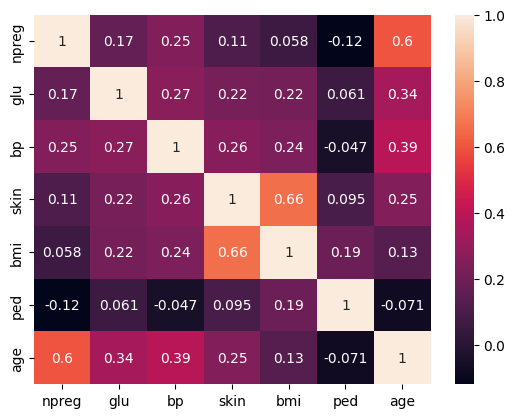

In [8]:
#Normally to check the correaltion we use the heatmap the ease our visual intrepatation

import seaborn as sns

sns.heatmap(pima.corr(numeric_only=True),annot=True)

In [9]:
#Based on the correlation map the input(skin) : output(bmi) is linear to each other corr value 0.66 almost close to 0.7

#Input
X = pima[['skin']]
#Output
y = pima['bmi']

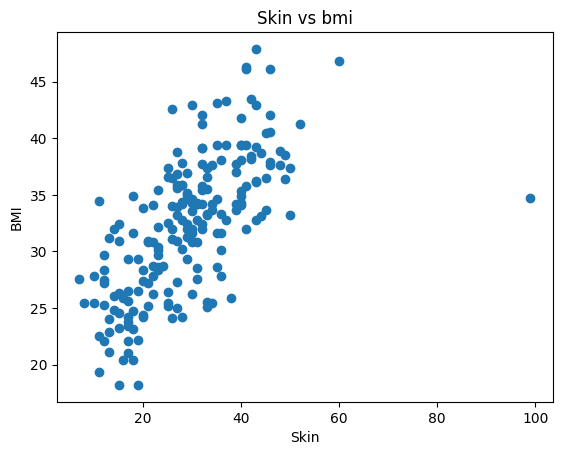

In [10]:
plt.scatter(X,y)

plt.xlabel("Skin")
plt.ylabel("BMI")
plt.title("Skin vs bmi")

plt.show()

# Step 2 : Train Test Split

`Refer` : https://drive.google.com/file/d/10uuelMm0UONDJQvdrX5yiNknv7k9UWix/view?usp=sharing

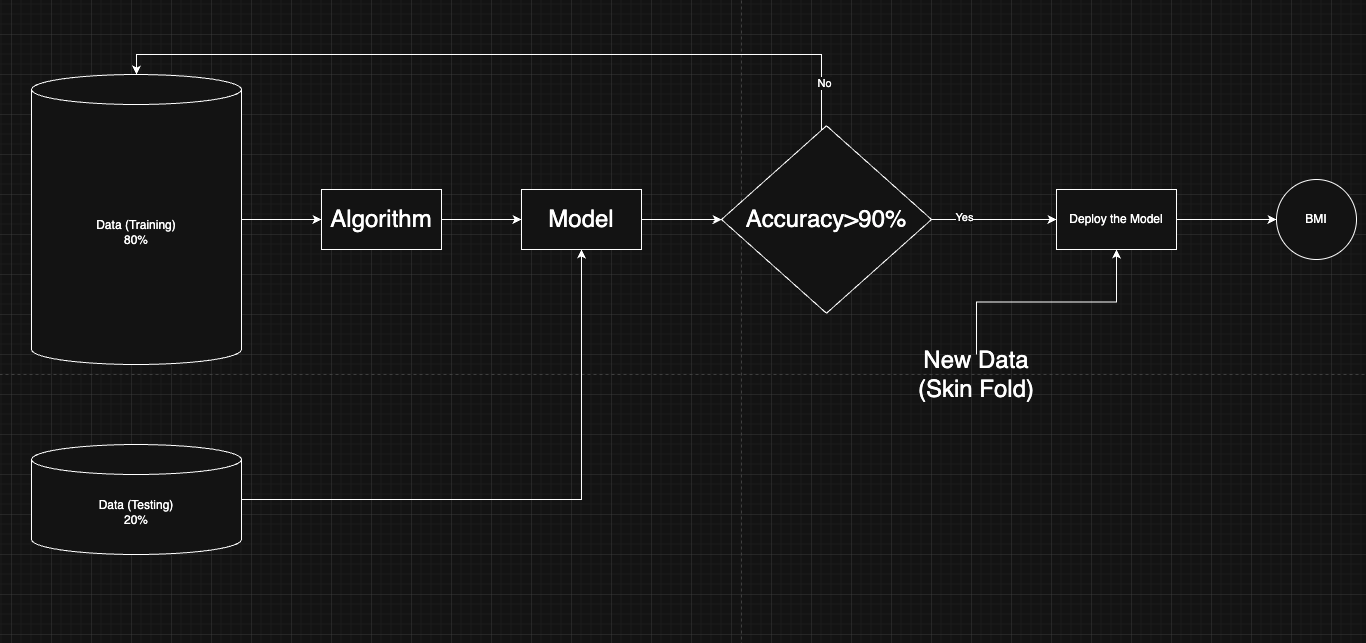

In [11]:
# 1. use training data (x train & train y) to plot the model
# 2. get y-predict from the model using x test
# 3. compare y-test and y-predict --> to evluate the model/error

# y-test = actual y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

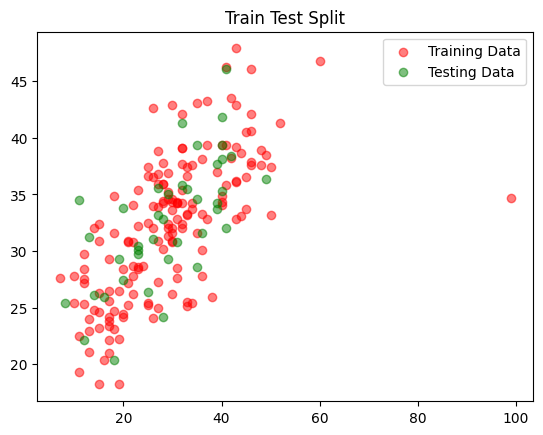

In [12]:
#train test split visualisation

plt.scatter(X_train,y_train, label ="Training Data", color="r", alpha= 0.5)
plt.scatter(X_test,y_test, label ="Testing Data", color="g", alpha= 0.5)

plt.legend()

plt.title("Train Test Split")

plt.show()

---
## Step 3: Create our Linear Model

Create the model from our training data.

In [13]:
model = LinearRegression()#Alogrithm
model.fit(X_train, y_train)#Fit the data to the algorithm

LinearRegression()

---

## Step 4: Visual our model against actual test data

Basically `y test` vs `y predict`

In [14]:
y_pred = model.predict(X_test)

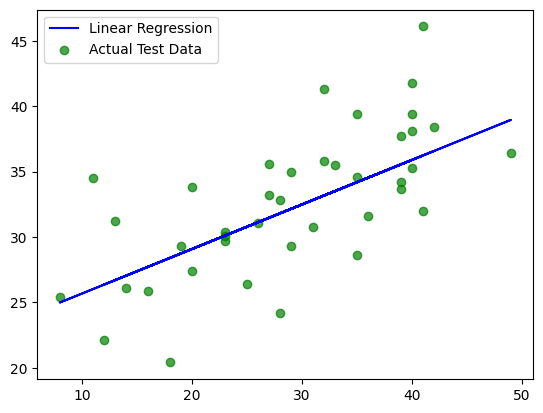

In [15]:
plt.plot(X_test,y_pred,label = "Linear Regression",color = 'b')
plt.scatter(X_test,y_test, label = "Actual Test Data",color = "g",alpha = .7)

plt.legend()
plt.show()

---
## Step 5: New x to predict y

In [16]:
bmi = int(input("Please provide your skin fold."))

prediction = model.predict(np.array([[bmi]]))[0]

print(f"The predicted BMI is {prediction}.")

Please provide your skin fold.28
The predicted BMI is 31.79728182961312.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## Step 6: Evaluate the model

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")


#Rule the lower your MSE and RMSE and more accurate your model is.

Mean Squared Error: 16.37059983983064
Root Mean Squared Error: 4.046059791924811


Text(0.5, 1.0, 'Predicted vs Accual')

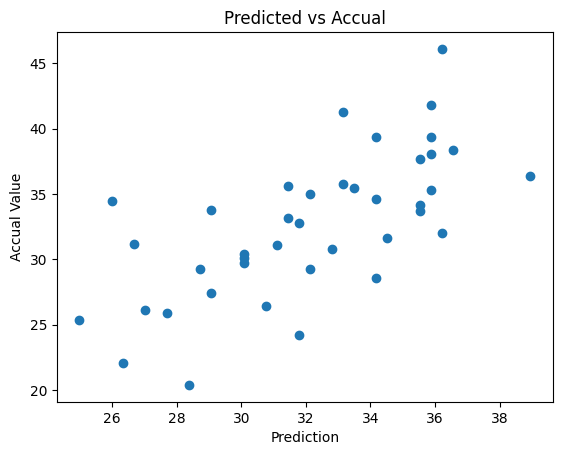

In [23]:
#Y Pred is predicted
#Y Test is accual data

plt.scatter(y_pred,y_test)
plt.xlabel("Prediction")
plt.ylabel("Accual Value")
plt.title("Predicted vs Accual")

#Exercise (Study Score)

#Import the data

In [24]:
df = pd.read_csv("/content/linear_regression_practice_data.csv")

In [25]:
df.head()

,Student_ID,Hours_Studied,Exam_Score
0,1,1.0,45
1,2,1.5,51
2,3,2.0,50
3,4,2.5,60
4,5,3.0,62


#Check the corelation

<Axes: >

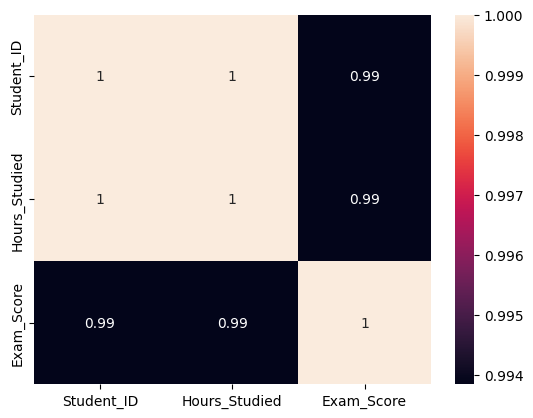

In [27]:
corr = df.corr()

sns.heatmap(corr,annot = True)

#Split the data to input and output

In [28]:
X = df[['Hours_Studied']]#Input
y = df['Exam_Score']#Output

#Split the data into testing and training

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Train the data

In [30]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

#Evalutate the model performance

In [33]:
y_pred = model.predict(X_test) #Predicted output

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Squared Error: 0.88
Root Mean Squared Error: 0.94


In [34]:
df.head()

,Student_ID,Hours_Studied,Exam_Score
0,1,1.0,45
1,2,1.5,51
2,3,2.0,50
3,4,2.5,60
4,5,3.0,62


#Test your model with new data

In [38]:
hours = float(input("Please provide your study hours : "))

prediction = model.predict(np.array([[hours]]))[0]

print(f"The predicted exam score is {prediction:.2f}.")

Please provide your study hours : 8
The predicted exam score is 103.22.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Predicted vs Accual')

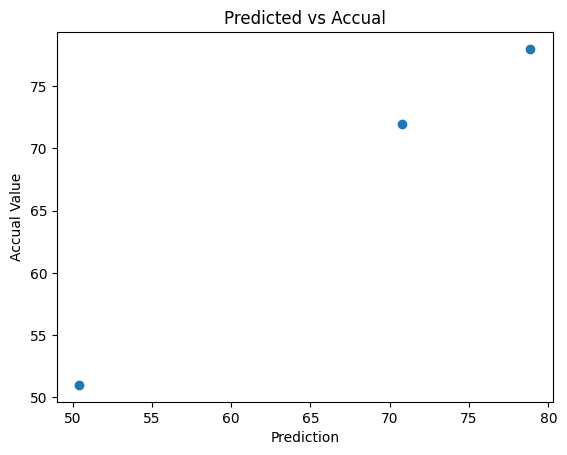

In [39]:
plt.scatter(y_pred,y_test)
plt.xlabel("Prediction")
plt.ylabel("Accual Value")
plt.title("Predicted vs Accual")

#2.Multiple Linear Regression

#Inport data

In [40]:
df = pd.read_csv("/content/multiple_linear_regression_data.csv")

In [41]:
df.head()

,Student_ID,Hours_Studied,Attendance_Rate,Exam_Score
0,1,4.0,84.0,71.0
1,2,8.6,67.0,91.0
2,3,6.9,63.0,82.0
3,4,5.8,98.0,92.0
4,5,2.2,99.0,72.0


#Check for the corelation

<Axes: >

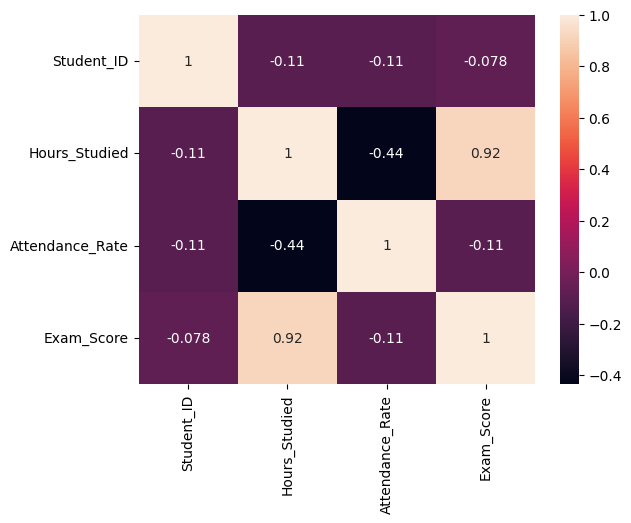

In [42]:
corr = df.corr()
sns.heatmap(corr,annot = True)

In [45]:
X = df[['Hours_Studied','Attendance_Rate']]#Input
y = df['Exam_Score']#Output

#Train test split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Train the model

In [47]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

#Evaluate the model

In [49]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Squared Error: 7.56
Root Mean Squared Error: 2.75


In [51]:
df.head()

,Student_ID,Hours_Studied,Attendance_Rate,Exam_Score
0,1,4.0,84.0,71.0
1,2,8.6,67.0,91.0
2,3,6.9,63.0,82.0
3,4,5.8,98.0,92.0
4,5,2.2,99.0,72.0


#Test the model with new data

In [52]:
hours = float(input("Please provide your study hours : "))
attendance = float(input("Please provide your attendance rate : "))

prediction = model.predict(np.array([[hours,attendance]]))[0]

print(f"The predicted exam score is {prediction:.2f}.")

Please provide your study hours : 4
Please provide your attendance rate : 84
The predicted exam score is 74.14.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#Visualize the accual performance

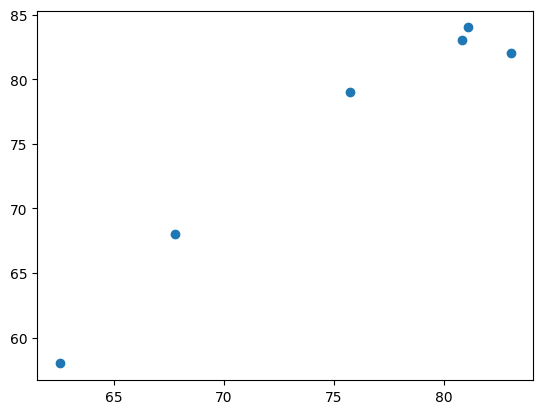

In [53]:
plt.scatter(y_pred,y_test)

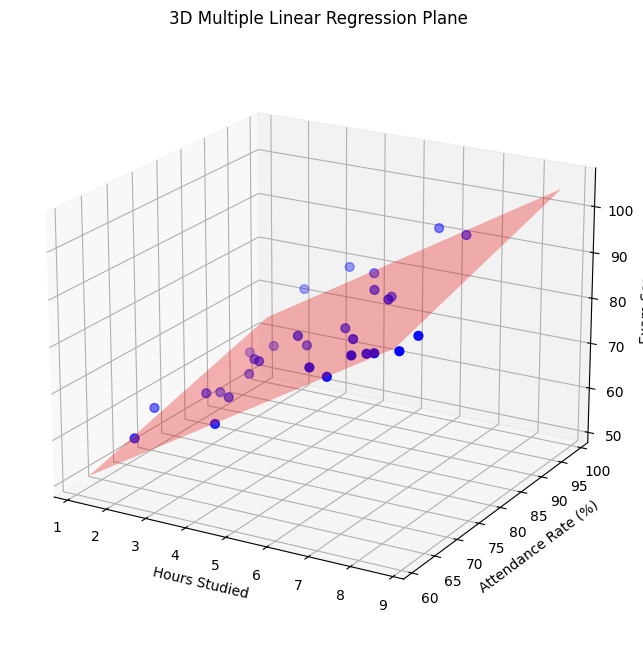

In [59]:
# 3. Create a 3D Meshgrid to plot the prediction plane
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate coordinates for the plane
x_surf = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 20)
y_surf = np.linspace(df['Attendance_Rate'].min(), df['Attendance_Rate'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Predict Y over the meshgrid coordinates
ex_pred = pd.DataFrame({'Hours_Studied': x_surf.ravel(), 'Attendance_Rate': y_surf.ravel()})
z_surf = model.predict(ex_pred).reshape(x_surf.shape)

# 4. Plot the regression plane and actual data points
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3, label='Regression Plane')
ax.scatter(df['Hours_Studied'], df['Attendance_Rate'], df['Exam_Score'], color='blue', s=40, label='Actual Students')


# Labels and View Angle
ax.set_title('3D Multiple Linear Regression Plane')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Attendance Rate (%)')
ax.set_zlabel('Exam Score')
ax.view_init(elev=20, azim=-60) # Adjust view angle to clearly see the slope

plt.show()